# 1. Introduction

##a. Goal of the project

No code needed for this part of the report.

##b. Data overview

### Connecting Google Drive

In [ ]:
# connect GoogleColab with my GoogleDrive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# store prefix path to access all files on my google drive
prefix_path = '/content/drive/My Drive/KeepCoding/DeepLearning/Practica/'

Mounted at /content/drive


### Reading data file

In [ ]:
# import Python libraries
import numpy as np
import pandas as pd

# read metadata file
df_raw = pd.read_csv(prefix_path + 'poi_dataset.csv', sep=',')
print(f"Size of metadata file: {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.\n")
print(f"Titles of columns: \n {df_raw.columns.tolist()}")

Size of metadata file: 1569 rows and 14 columns.

Titles of columns: 
 ['id', 'name', 'shortDescription', 'categories', 'tier', 'locationLon', 'locationLat', 'tags', 'xps', 'Visits', 'Likes', 'Dislikes', 'Bookmarks', 'main_image_path']


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1569 entries, 0 to 1568
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1569 non-null   object 
 1   name              1569 non-null   object 
 2   shortDescription  1569 non-null   object 
 3   categories        1569 non-null   object 
 4   tier              1569 non-null   int64  
 5   locationLon       1569 non-null   float64
 6   locationLat       1569 non-null   float64
 7   tags              1569 non-null   object 
 8   xps               1569 non-null   int64  
 9   Visits            1569 non-null   int64  
 10  Likes             1569 non-null   int64  
 11  Dislikes          1569 non-null   int64  
 12  Bookmarks         1569 non-null   int64  
 13  main_image_path   1569 non-null   object 
dtypes: float64(2), int64(6), object(6)
memory usage: 171.7+ KB


In [ ]:
df_raw.head(5)

,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,Galería Fran Reus,La Galería Fran Reus es un espacio dedicado a ...,"['Escultura', 'Pintura']",1,2.642262,39.572694,[],500,10009,422,3582,78,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...
1,e32b3603-a94f-49df-8b31-92445a86377c,Convento de San Plácido,"El Convento de San Plácido en Madrid, fundado ...","['Patrimonio', 'Historia']",1,-3.704467,40.423037,[],500,10010,7743,96,2786,data_main/e32b3603-a94f-49df-8b31-92445a86377c...
2,0123a69b-13ac-4b65-a5d5-71a95560cff5,Instituto Geológico y Minero de España,"El Instituto Geológico y Minero de España, sit...","['Ciencia', 'Patrimonio']",2,-3.699694,40.442045,[],250,10015,3154,874,595,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...
3,390d7d9e-e972-451c-b5e4-f494af15e788,Margarita Gil Roësset,"Margarita Gil Roësset, escultora y poetisa esp...",['Cultura'],1,-3.691228,40.427256,[],500,10011,8559,79,2358,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...
4,023fc1bf-a1cd-4b9f-af78-48792ab1a294,Museo del Traje. Centro de Investigación del P...,"El Museo del Traje de Madrid, fundado en 2004,...","['Patrimonio', 'Cultura']",1,-3.727822,40.439665,[],500,10020,915,2896,143,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...


#2. Approach and data quality assessment

##a. Model architecture approach



No code is needed for this part of the report.


##b. Variables to use for prediction target (engagement metric)

In [ ]:
# summary statistics of all raw data
df_raw.describe()

,tier,locationLon,locationLat,xps,Visits,Likes,Dislikes,Bookmarks
count,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000
mean,1.541109,-1.132337,39.900141,750.382409,10011.943276,3623.908222,2526.305927,973.261950
std,0.637677,22.733401,9.662134,228.319854,5.456808,4817.879374,2225.543360,1453.333948
min,1.000000,-121.951049,-62.940930,0.000000,10001.000000,100.000000,52.000000,50.000000
25%,1.000000,-3.725292,40.411754,600.000000,10008.000000,464.000000,937.000000,116.000000
50%,1.000000,-3.699140,40.421738,700.000000,10011.000000,1434.000000,2718.000000,306.000000
75%,2.000000,-3.673348,40.472458,1000.000000,10015.000000,6840.000000,3399.000000,1309.000000
max,4.000000,158.333118,65.706572,1000.000000,10038.000000,26425.000000,10999.000000,8157.000000


Contrary to the other numerical variables, 'Visits' has very little variability: all values are between 10001 and 10038, with a mean of 10012 and a standard deviation of 5.5. For practical purposes, it is essentially a constant in the data.

I will draw graphs to visualize whether, despite my comment above, there might be any kind of correlation between 'Visits' and the other variables.

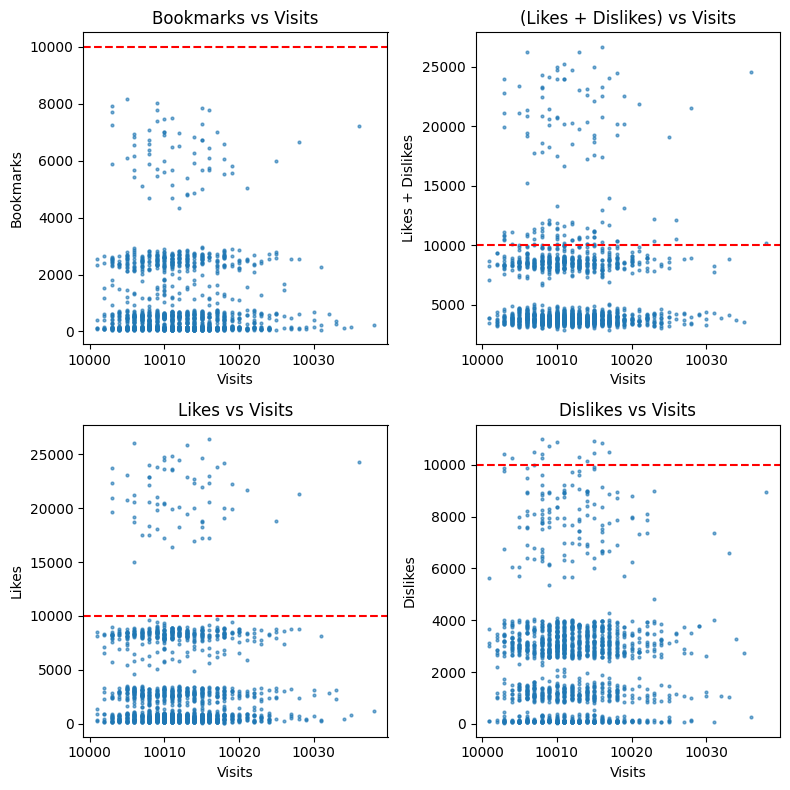

In [ ]:
# draw graphs of engagement-related variables vs 'Visits'

import matplotlib.pyplot as plt

# create the figure and axes for 4 plots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# top-left: 'Bookmarks' vs 'Visits'
axes[0, 0].scatter(df_raw["Visits"], df_raw["Bookmarks"], s=4, alpha=0.6)
axes[0, 0].set_title("Bookmarks vs Visits")
axes[0, 0].set_xlabel("Visits")
axes[0, 0].set_ylabel("Bookmarks")

# top-right: ('Likes' + 'Dislikes') vs 'Visits'
axes[0, 1].scatter(df_raw["Visits"], df_raw["Likes"] + df_raw["Dislikes"], s=4, alpha=0.6)
axes[0, 1].set_title("(Likes + Dislikes) vs Visits")
axes[0, 1].set_xlabel("Visits")
axes[0, 1].set_ylabel("Likes + Dislikes")

# bottom-left: 'Likes' vs 'Visits'
axes[1, 0].scatter(df_raw["Visits"], df_raw["Likes"], s=4, alpha=0.6)
axes[1, 0].set_title("Likes vs Visits")
axes[1, 0].set_xlabel("Visits")
axes[1, 0].set_ylabel("Likes")

# bottom-right: 'Dislikes' vs 'Visits'
axes[1, 1].scatter(df_raw["Visits"], df_raw["Dislikes"], s=4, alpha=0.6)
axes[1, 1].set_title("Dislikes vs Visits")
axes[1, 1].set_xlabel("Visits")
axes[1, 1].set_ylabel("Dislikes")

# plot a horizontal line showing the median number of 'Visits'
for axis in axes.flat:
  axis.axhline(y = 10011, color="red", linestyle="--")

# improve layout
plt.tight_layout()
plt.show()


The red line shows the approximately constant value of 'Visits', in order to better notice when the other metrics are above this value.

##c. Non-numerical metadata variables




In [ ]:
# display last rows
df_raw.tail()

,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
1564,a1058fc5-8b4e-43db-8758-2a4197eb69ca,"Plaza de Puerta Cerrada, en Madrid","ANTONIO ORBEGOZO\nPlaza de Puerta Cerrada, en ...",['Pintura'],1,-3.707943,40.413677,['Cruz'],600,10014,8174,63,2150,data_main/a1058fc5-8b4e-43db-8758-2a4197eb69ca...
1565,77df8476-484e-436e-8977-f957f6b9371a,¡Aquel Madrid!,"JUAN ESPLANDIÚ PEÑA\n¡Aquel Madrid!\nABC, núm....",['Pintura'],1,-3.689120,40.416555,"['Puerta', 'Parque del Retiro']",600,10013,679,2963,107,data_main/77df8476-484e-436e-8977-f957f6b9371a...
1566,21c741f5-cbe7-4ae0-a69d-b5c1622056af,El viento se acuesta al atardecer,SERNY (Ricardo Summers e Isern)\nEl viento se ...,['Pintura'],1,-3.712121,40.419088,"['Estatuas', 'Plaza']",600,10005,926,2913,180,data_main/21c741f5-cbe7-4ae0-a69d-b5c1622056af...
1567,4b8b38fa-78b5-4ea8-a676-1de4e2b48caa,Edificio Metrópolis por Herreros,HERREROS (Enrique García-Herreros Codesido)\nS...,['Pintura'],1,-3.695836,40.418698,"['Alcalá', 'Gran Vía', 'Metrópolis']",600,10006,4615,2797,932,data_main/4b8b38fa-78b5-4ea8-a676-1de4e2b48caa...
1568,d7f45b8d-c311-4309-a85a-d91f1fcd3b2f,Monasterio de Moreruela,"Descubre el Monasterio de Moreruela, una joya ...","['Patrimonio', 'Historia', 'Arquitectura']",1,-5.777600,41.812321,"['Arquitectura', 'Cisterciense', 'Císter', 'Mo...",500,10011,8623,93,2749,data_main/d7f45b8d-c311-4309-a85a-d91f1fcd3b2f...


In [ ]:
# count unique values in each column

unique_counts = {col: df_raw[col].nunique() for col in df_raw.columns}

print(unique_counts)

{'id': 1492, 'name': 1458, 'shortDescription': 1491, 'categories': 224, 'tier': 4, 'locationLon': 1437, 'locationLat': 1439, 'tags': 1418, 'xps': 13, 'Visits': 37, 'Likes': 1241, 'Dislikes': 1154, 'Bookmarks': 819, 'main_image_path': 1492}


In [ ]:
# calculate length of text entries
lengths = {
    'id_length': df_raw['id'].str.len(),
    'name_length': df_raw['name'].str.len(),
    'shortDescription_length': df_raw['shortDescription'].str.len(),
    'categories_length': df_raw['categories'].str.len(),
    'tags_length': df_raw['tags'].str.len(),
    'main_image_path_length': df_raw['main_image_path'].str.len()
}

df_lengths = pd.DataFrame(lengths)

# display summary statistics
df_lengths.describe()


,id_length,name_length,shortDescription_length,categories_length,tags_length,main_image_path_length
count,1569.0,1569.000000,1569.000000,1569.000000,1569.000000,1569.0
mean,36.0,29.413002,120.384959,38.492033,122.543658,55.0
std,0.0,13.804631,24.569735,8.455396,69.577173,0.0
min,36.0,4.000000,16.000000,2.000000,2.000000,55.0
25%,36.0,20.000000,110.000000,36.000000,54.000000,55.0
50%,36.0,27.000000,117.000000,39.000000,144.000000,55.0
75%,36.0,36.000000,125.000000,42.000000,176.000000,55.0
max,36.0,114.000000,504.000000,55.000000,275.000000,55.0


In [ ]:
# check specific classes of "object" Dtypes for 'categories' and 'tags'
print("The 'categories' column contains data of type: ", type(df_raw['categories'][0]))
print("The 'tags' column contains data of type: ", type(df_raw['tags'][0]))

The 'categories' column contains data of type:  <class 'str'>
The 'tags' column contains data of type:  <class 'str'>


Even though 'categories' and 'tags' appear to be lists from a visual inspection of the values in the dataframe, they are actually catalogued as strings.
They should be converted to lists so they can be successfully multilabel encoded.

###i. ‘categories’ and ‘tags’ to lists


In [ ]:
# change class 'str' into class 'list' for 'categories' and 'tags'
import ast
df_raw['categories'] = df_raw['categories'].apply(ast.literal_eval)
df_raw['tags'] = df_raw['tags'].apply(ast.literal_eval)
print("The 'categories' column contains data of type: ", type(df_raw['categories'][0]))
print("The 'tags' column contains data of type: ", type(df_raw['tags'][0]))


The 'categories' column contains data of type:  <class 'list'>
The 'tags' column contains data of type:  <class 'list'>


In [ ]:
# finding out what the different values of 'categories' and 'tags' are and their frequency

# flatten the lists
unique_categories = set(cat for row in df_raw['categories'] for cat in row)
unique_tags = set(tag for row in df_raw['tags'] for tag in row)

# count how many times each category and tag appears (frequency)
cat_counts = df_raw['categories'].explode().value_counts()
tag_counts = df_raw['tags'].explode().value_counts()

# display results
print(f"There are {len(unique_categories)} different categories, and their frequency is: \n{cat_counts}")
print(f"\nThere are {len(unique_tags)} different tags, with the most frequent being: \n{tag_counts.head(15)}")

There are 12 different categories, and their frequency is: 
categories
Historia        1297
Cultura         1030
Arquitectura     660
Patrimonio       603
Escultura        482
Misterio         382
Ciencia          132
Ocio              76
Pintura           48
Naturaleza        43
Cine              23
Gastronomía       18
Name: count, dtype: int64

There are 2935 different tags, with the most frequent being: 
tags
Historia                            802
Madrid                              700
Cultura                             583
Arquitectura                        398
Patrimonio                          353
Arte                                329
Escultura                           328
Estatua                             269
Monumento                           166
Naturaleza                          150
Restauración                        131
Grupo escultórico                   102
Educación                            98
Escultura conceptual o abstracta     97
Centro                 

In [ ]:
# find which categories, if any, are NOT in 'tags'
categories_not_in_tags = unique_categories - unique_tags
print("This is the set of 'categories' not present in 'tags':\n", categories_not_in_tags)

This is the set of 'categories' not present in 'tags':
 set()


In [ ]:
# count number of categories and tags per row

df_counts = df_raw.copy()
df_counts['categories_count'] = df_counts['categories'].apply(len)
df_counts['tags_count'] = df_counts['tags'].apply(len)
print(f"Summary statistics on number of categories per row: \n {df_counts['categories_count'].describe()}")
print(f"\nSummary statistics on number of tags per row: \n {df_counts['tags_count'].describe()}")


Summary statistics on number of categories per row: 
 count    1569.000000
mean        3.055449
std         0.666326
min         0.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         4.000000
Name: categories_count, dtype: float64

Summary statistics on number of tags per row: 
 count    1569.000000
mean        8.483110
std         4.567507
min         0.000000
25%         4.000000
50%        10.000000
75%        13.000000
max        13.000000
Name: tags_count, dtype: float64


To see whether 'categories' would be a good feature to encode I will draw boxplots that show the distribution of Bookmarks, Likes, and Dislikes by category.

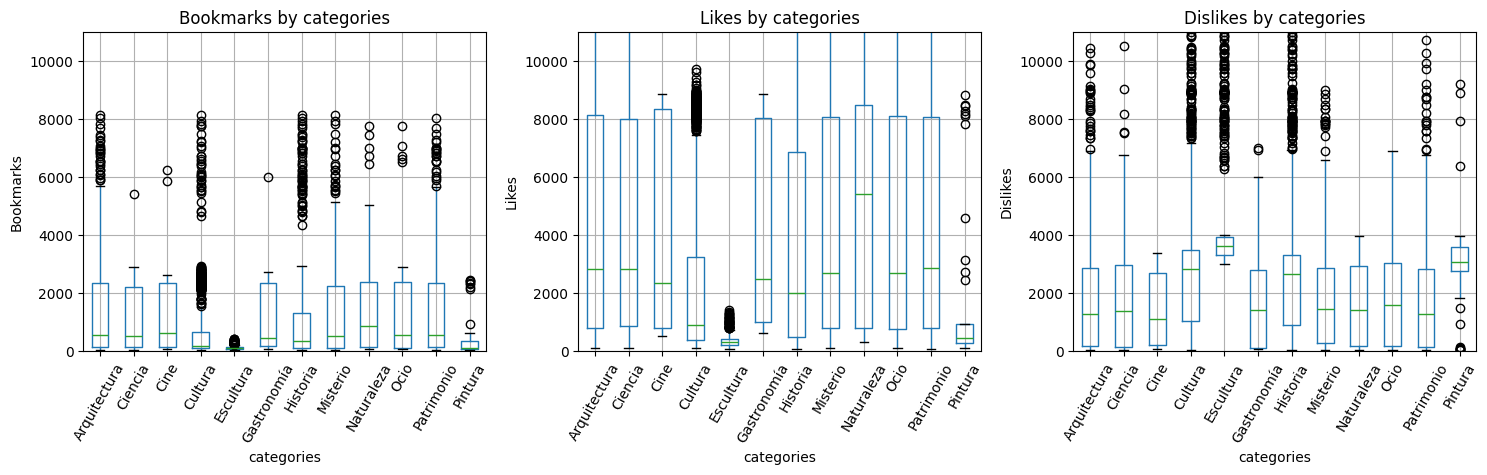

In [ ]:
# draw boxplots of 'Bookmarks', 'Likes' and 'Dislikes' by category

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# prepare data for plotting
# explode the 'categories' column to create a new row for each category
df_exploded = df_raw.explode('categories')

# create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# set a common maximum y-value on all plots to better compare them
max_y_value = 11000

# define the y columns to plot
y_cols = ['Bookmarks', 'Likes', 'Dislikes']
titles = ["Bookmarks by categories", "Likes by categories", "Dislikes by categories"]

# loop through the y columns to generate the boxplots
for ax, y_col, title in zip(axes, y_cols, titles):
  # generate boxplot
  df_exploded.boxplot(column=y_col, by='categories', ax=ax)
  ax.set_title(title)
  ax.set_ylim(0, max_y_value)
  ax.set_ylabel(y_col)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60)

# adjust layout
plt.suptitle('')  # no overall title needed
plt.tight_layout()
plt.show()


Similarly, I will create boxplots of 'Bookmarks', 'Likes', and 'Dislikes' by tag count per row.

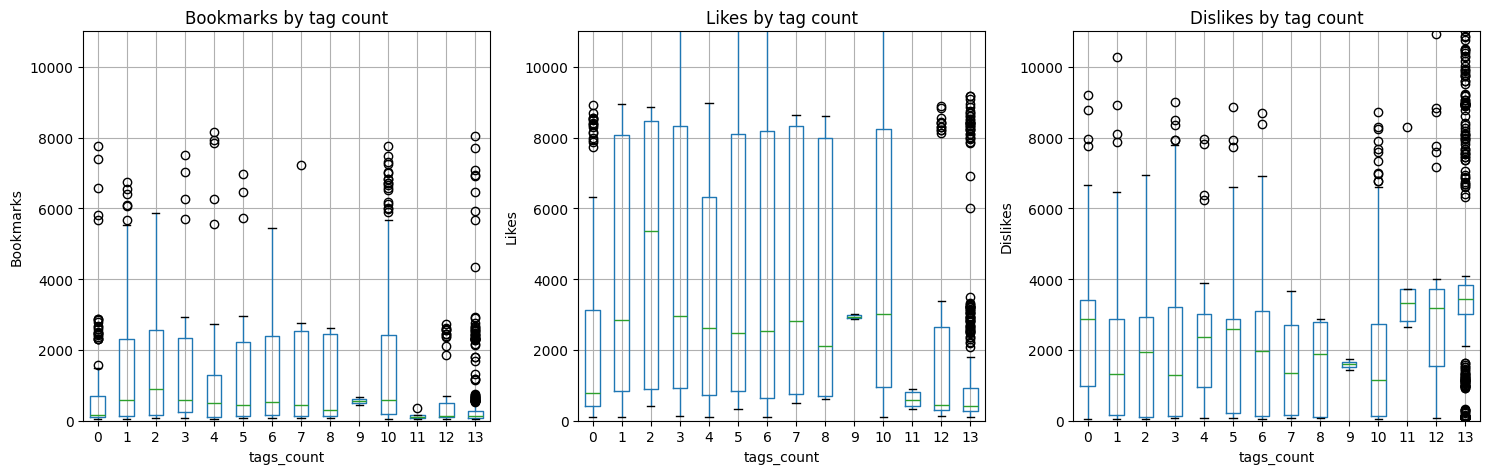

In [ ]:
# draw boxplots of 'Bookmarks', 'Likes' and 'Dislikes' by tag count

import pandas as pd
import matplotlib.pyplot as plt

# create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# define the y columns to plot and titles
y_cols = ['Bookmarks', 'Likes', 'Dislikes']
titles = ["Bookmarks by tag count", "Likes by tag count", "Dislikes by tag count"]

# define the maximum y-value (for easier comparison)
max_y_value = 11000

# loop through the y columns to generate the boxplots
for ax, y_col, title in zip(axes, y_cols, titles):
  # generate boxplot
  df_counts.boxplot(column=y_col, by='tags_count', ax=ax)
  ax.set_title(title)
  ax.set_ylim(0, max_y_value)
  ax.set_ylabel(y_col)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# adjust layout
plt.suptitle('')  # no overall title needed
plt.tight_layout()
plt.show()


Similarly with categories count, even though this is not mentioned in the report.

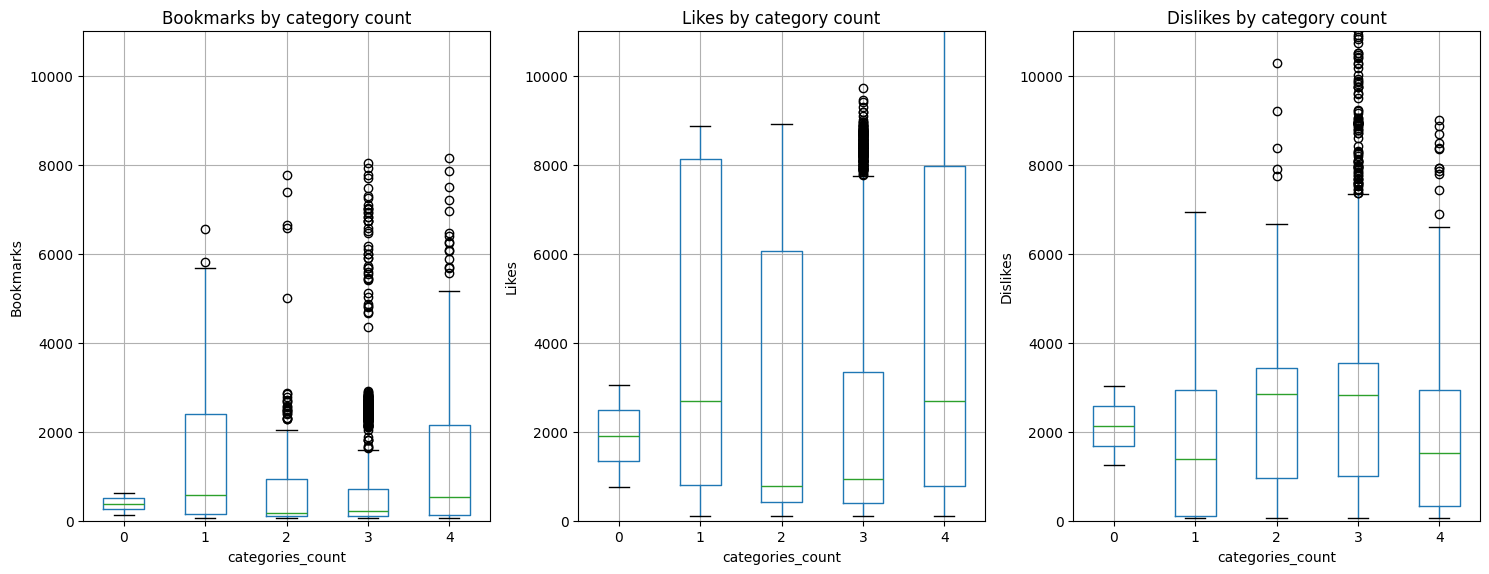

In [ ]:
# draw boxplots of 'Bookmarks', 'Likes' and 'Dislikes' by category count

import pandas as pd
import matplotlib.pyplot as plt

# create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# define the y columns to plot and titles
y_cols = ['Bookmarks', 'Likes', 'Dislikes']
titles = ["Bookmarks by category count", "Likes by category count", "Dislikes by category count"]

# define the maximum y-value (for easier comparison)
max_y_value = 11000

# loop through the y columns to generate the boxplots
for ax, y_col, title in zip(axes, y_cols, titles):
  # generate boxplot
  df_counts.boxplot(column=y_col, by='categories_count', ax=ax)
  ax.set_title(title)
  ax.set_ylim(0, max_y_value)
  ax.set_ylabel(y_col)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
'''
# create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# generate boxplots for Bookmarks by cat_count
df_counts.boxplot(column='Bookmarks', by='categories_count', ax=axes[0])
axes[0].set_title('Bookmarks by category count')
axes[0].set_ylabel('Bookmarks')
axes[0].set_ylim(0, max_y_value)  # set y-axis limits
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# generate boxplots for Likes by tags_count
df_counts.boxplot(column='Likes', by='categories_count', ax=axes[1])
axes[1].set_title('Likes by category count')
axes[1].set_ylabel('Likes')
axes[1].set_ylim(0, max_y_value)  # set y-axis limits
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

# generate boxplots for Dislikes by tags_count
df_counts.boxplot(column='Dislikes', by='categories_count', ax=axes[2])
axes[2].set_title('Dislikes by category count')
axes[2].set_ylabel('Dislikes')
axes[2].set_ylim(0, max_y_value)  # set y-axis limits
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)
'''
# adjust layout
plt.suptitle('')  # no overall title needed
plt.tight_layout()
plt.show()

In [ ]:
# count and display rows with missing categories (list length = 0)
print(f"Number of rows with missing categories: {(df_raw['categories'].apply(len) == 0).sum()}")

df_missing_cat_rows = df_raw[df_raw['categories'].apply(len) == 0]

df_missing_cat_rows.head()

Number of rows with missing categories: 2


,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
24,e8cff95b-b4dd-46fd-82cc-800966e4b575,Teatro de la Zarzuela,"El Teatro de la Zarzuela, emblema cultural de ...",[],2,-3.696890,40.417202,[],500,10011,3057,1242,624,data_main/e8cff95b-b4dd-46fd-82cc-800966e4b575...
26,4b290ed0-94a4-40f1-9b5c-e11c1a4bc950,Teatro María Guerrero,"El Teatro María Guerrero, situado en Madrid, e...",[],1,-3.692992,40.422884,[],500,10015,760,3022,133,data_main/4b290ed0-94a4-40f1-9b5c-e11c1a4bc950...


In [ ]:
# count and display rows with missing tags (list length = 0)
print(f"Number of rows with missing tags: {(df_raw['tags'].apply(len) == 0).sum()}")

df_missing_tag_rows = df_raw[df_raw['tags'].apply(len) == 0]

df_missing_tag_rows.head()

Number of rows with missing tags: 107


,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,Galería Fran Reus,La Galería Fran Reus es un espacio dedicado a ...,"[Escultura, Pintura]",1,2.642262,39.572694,[],500,10009,422,3582,78,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...
1,e32b3603-a94f-49df-8b31-92445a86377c,Convento de San Plácido,"El Convento de San Plácido en Madrid, fundado ...","[Patrimonio, Historia]",1,-3.704467,40.423037,[],500,10010,7743,96,2786,data_main/e32b3603-a94f-49df-8b31-92445a86377c...
2,0123a69b-13ac-4b65-a5d5-71a95560cff5,Instituto Geológico y Minero de España,"El Instituto Geológico y Minero de España, sit...","[Ciencia, Patrimonio]",2,-3.699694,40.442045,[],250,10015,3154,874,595,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...
3,390d7d9e-e972-451c-b5e4-f494af15e788,Margarita Gil Roësset,"Margarita Gil Roësset, escultora y poetisa esp...",[Cultura],1,-3.691228,40.427256,[],500,10011,8559,79,2358,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...
4,023fc1bf-a1cd-4b9f-af78-48792ab1a294,Museo del Traje. Centro de Investigación del P...,"El Museo del Traje de Madrid, fundado en 2004,...","[Patrimonio, Cultura]",1,-3.727822,40.439665,[],500,10020,915,2896,143,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...


###ii. Duplicates of ‘id’, ‘main_image_path’, ‘name’, and ‘shortDescription’

In [ ]:
# check for rows with duplicate 'id'
df_duplicates_id = df_raw[df_raw.duplicated(subset='id', keep=False)]  #keep=False marks all duplicates as True (by default the first one would be marked False)

# check for rows with duplicate 'main_image_path'
df_duplicates_imgpath = df_raw[df_raw.duplicated(subset='main_image_path', keep=False)]

# display indices of row with duplicates
print(f"There are {len(df_duplicates_id)} row numbers with a duplicate 'id':\n{df_duplicates_id.index}")
print(f"There are {len(df_duplicates_imgpath)} row numbers with a duplicate 'main_image_path':\n{df_duplicates_imgpath.index}")


There are 100 row numbers with a duplicate 'id':
Index([1178, 1179, 1180, 1181, 1232, 1233, 1234, 1235, 1236, 1244, 1245, 1246,
       1247, 1248, 1249, 1272, 1273, 1274, 1275, 1276, 1295, 1296, 1297, 1298,
       1299, 1300, 1301, 1302, 1304, 1305, 1306, 1307, 1317, 1318, 1319, 1344,
       1345, 1346, 1347, 1385, 1386, 1387, 1388, 1390, 1391, 1392, 1393, 1402,
       1403, 1404, 1405, 1406, 1407, 1417, 1418, 1419, 1420, 1421, 1422, 1423,
       1424, 1425, 1426, 1477, 1478, 1479, 1480, 1481, 1484, 1485, 1486, 1487,
       1488, 1489, 1508, 1509, 1510, 1511, 1512, 1513, 1514, 1515, 1516, 1517,
       1519, 1520, 1521, 1522, 1523, 1524, 1545, 1546, 1547, 1549, 1550, 1551,
       1552, 1553, 1554, 1555],
      dtype='int64')
There are 100 row numbers with a duplicate 'main_image_path':
Index([1178, 1179, 1180, 1181, 1232, 1233, 1234, 1235, 1236, 1244, 1245, 1246,
       1247, 1248, 1249, 1272, 1273, 1274, 1275, 1276, 1295, 1296, 1297, 1298,
       1299, 1300, 1301, 1302, 1304, 1305, 130

In [ ]:
# check whether the two dataframes are equal
assert df_duplicates_id.equals(df_duplicates_imgpath), "Error: dataframes are not identical"

Now that we know that the rows where 'id' is duplicate are the same as the rows where 'main_image_path' is duplicate, let's take a look at these rows.

In [ ]:
# display rows with duplicates
df_duplicates_id.head(5)  # Use 50 in head() and tail() to visualize all rows
df_duplicates_id.tail(5)

,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
1551,f67f254e-da95-40ef-820c-602a2d09e979,El Ateneo Gran Splendid,"El Ateneo Grand Splendid, ubicado en Buenos Ai...",[Cultura],2,-58.394205,-34.595993,[música],250,10017,8111,73,2497,data_main/f67f254e-da95-40ef-820c-602a2d09e979...
1552,e5427b0f-dd8c-4a31-bbe2-9c31a654a464,Museo de Arte Latinoamericano de Buenos Aires,"El MALBA, inaugurado en 2001, es un museo dedi...","[Escultura, Pintura, Cultura]",1,-58.403419,-34.576989,[Cultura latinoamericana],250,10008,314,8909,137,data_main/e5427b0f-dd8c-4a31-bbe2-9c31a654a464...
1553,e5427b0f-dd8c-4a31-bbe2-9c31a654a464,Museo de Arte Latinoamericano de Buenos Aires,"El MALBA, inaugurado en 2001, es un museo dedi...","[Escultura, Pintura, Cultura]",1,-58.403419,-34.576989,[Museo],250,10014,261,3009,113,data_main/e5427b0f-dd8c-4a31-bbe2-9c31a654a464...
1554,d5c11570-41c3-40d2-bc1a-b3217780cd2c,Estatua de Adolfo Alsina,"La estatua de Adolfo Alsina, ubicada en la Pla...","[Patrimonio, Escultura]",2,-58.383450,-34.597431,[Adolfo Alsina],250,10018,104,3905,52,data_main/d5c11570-41c3-40d2-bc1a-b3217780cd2c...
1555,d5c11570-41c3-40d2-bc1a-b3217780cd2c,Estatua de Adolfo Alsina,"La estatua de Adolfo Alsina, ubicada en la Pla...","[Patrimonio, Escultura]",2,-58.383450,-34.597431,[Estatua],250,10008,586,10285,234,data_main/d5c11570-41c3-40d2-bc1a-b3217780cd2c...


From the visual inspection of the dataframe of duplicate 'id', it looks like the main differences between repeated rows are the 'tags', as well as sometimes 'xps', 'Visits', 'Likes', 'Dislikes', 'Bookmarks'.

In any case, it also seems that all of these rows only have one count of 'tags'. Let's check if this is indeed true.

In [ ]:
# count number of categories and tags per row in duplicates_id dataframe

df_duplicates_id['categories_count'] = df_duplicates_id['categories'].apply(len)
df_duplicates_id['tags_count'] = df_duplicates_id['tags'].apply(len)
print(f"Summary statistics on number of categories per row: \n {df_duplicates_id['categories_count'].describe()}")
print(f"\nSummary statistics on number of tags per row: \n {df_duplicates_id['tags_count'].describe()}")


Summary statistics on number of categories per row: 
 count    100.00000
mean       3.61000
std        0.80271
min        1.00000
25%        3.75000
50%        4.00000
75%        4.00000
max        4.00000
Name: categories_count, dtype: float64

Summary statistics on number of tags per row: 
 count    100.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: tags_count, dtype: float64


/tmp/ipython-input-3008125650.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_duplicates_id['categories_count'] = df_duplicates_id['categories'].apply(len)
/tmp/ipython-input-3008125650.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_duplicates_id['tags_count'] = df_duplicates_id['tags'].apply(len)


Indeed we see above that there are a minimum and maximum of 1 tag per row in all of these rows with duplicate ids.

In the code snippet below, I check the number of unique values of 'id' and other features. This should help to see in how many different rows these 100 rows with duplicates should be condensed.

In [ ]:
# count unique values of 'id', 'name', 'shortDescription' in each column of duplicates_id
columns_to_check = ['id','name', 'shortDescription', 'tier', 'locationLon',
                    'locationLat', 'xps','main_image_path']

unique_counts_duplicates_id = {
    col: df_duplicates_id[col].nunique()
    for col in columns_to_check
    if col in df_duplicates_id.columns
    }

unique_counts_duplicates_id


{'id': 23,
 'name': 23,
 'shortDescription': 23,
 'tier': 2,
 'locationLon': 23,
 'locationLat': 23,
 'xps': 2,
 'main_image_path': 23}

There are 23 unique counts, which means the 100 rows with repeat 'id' (and others) values should really only be 23 rows, with several 'tags' per row. Thus the 1569 rows actually correspond to:

1569 - 100  + 23 = 1492 entries.

Let's evaluate if this anomaly could be the cause that sometimes there were more reactions (likes, dislikes, or the sum of both) than visits. In the next snippet, I count the number of instances where there was a maximum of one tag and the number of reactions was higher than the number of visits.

In [ ]:
# count and display the rows where the 'tags' count is no more than 1 and 'Likes + Dislikes' > 'Visits'
# filtering the DataFrame based on the conditions
df_filtered_rows = df_raw[(df_raw['tags'].str.len() <= 1) &
                        ((df_raw['Likes'] + df_raw['Dislikes']) > df_raw['Visits'])]

# Display the count and the filtered rows
print(f"There are {df_filtered_rows.shape[0]} instances where 'Likes + Dislikes' > 'Visits' with no more than one tag.")
df_filtered_rows.tail(5)

There are 18 instances where 'Likes + Dislikes' > 'Visits' with no more than one tag.


,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
1479,48057ac3-5306-422f-95fa-0ff0937124bb,La Quinta da Regaleira,¡Explora La Quinta da Regaleira! Un palacio de...,"[Cultura, Arquitectura, Patrimonio, Misterio]",1,-9.395970,38.796383,[Religiones mistéricas],1000,10007,7386,3154,1769,data_main/48057ac3-5306-422f-95fa-0ff0937124bb...
1520,fde6f250-9196-4ca8-8351-a9e8b15a63b6,El Cementerio alemán de Gorlice,"Visita el Cementerio Alemán de Gorlice, un emo...","[Cultura, Patrimonio, Historia, Misterio]",1,21.159632,49.654616,[Primera Guerra Mundial],1000,10018,24233,255,6059,data_main/fde6f250-9196-4ca8-8351-a9e8b15a63b6...
1542,26abf2f5-2370-46e4-bbc2-05dc1124ab8c,Teatro Coliseo,"El Teatro Coliseo, ubicado en el barrio de Ret...",[Cultura],2,-58.383045,-34.596426,[teatro],250,10006,21181,153,6555,data_main/26abf2f5-2370-46e4-bbc2-05dc1124ab8c...
1547,651efcc9-29a8-4781-bf73-10dfa65a7d69,Palacio Barolo,"El Palacio Barolo, inaugurado en 1923, es un e...",[Cultura],2,-58.385910,-34.609677,[teatro],250,10010,6988,3715,1461,data_main/651efcc9-29a8-4781-bf73-10dfa65a7d69...
1555,d5c11570-41c3-40d2-bc1a-b3217780cd2c,Estatua de Adolfo Alsina,"La estatua de Adolfo Alsina, ubicada en la Pla...","[Patrimonio, Escultura]",2,-58.383450,-34.597431,[Estatua],250,10008,586,10285,234,data_main/d5c11570-41c3-40d2-bc1a-b3217780cd2c...


Fixing issues with rows with duplicate 'id'

1) Create a dataframe with the aggregated values for each POI:

*   all tags for each same repeated 'id' combined together into a new set
*   for these different rows with same 'id', I calculate the mean of each engagement metric and keep it as the aggregated value for this POI.

In [ ]:
# create array to store the duplicate 'id' values
dup_ids = df_duplicates_id['id'].unique()

# combine the rows POI by POI into a list
combined_rows = []

for poi_id in dup_ids:
  poi_group = df_duplicates_id[df_duplicates_id["id"] == poi_id]

  # combine and store the tags
  tags_set = set()
  for t in poi_group['tags']:
    tags_set.update(t)

  # calculate and store the means of engagement-related variables
  visits_mean = int(round(poi_group['Visits'].mean()))
  likes_mean = int(round(poi_group['Likes'].mean()))
  dislikes_mean = int(round(poi_group['Dislikes'].mean()))
  bookmarks_mean = int(round(poi_group['Bookmarks'].mean()))

  combined_rows.append({
      'id': poi_id,
      'tags': tags_set,
      'Visits': visits_mean,
      'Likes': likes_mean,
      'Dislikes': dislikes_mean,
      'Bookmarks': bookmarks_mean
  })

# convert the list of combined rows into a dataframe
df_combined_rows = pd.DataFrame(combined_rows)
df_combined_rows.head()

,id,tags,Visits,Likes,Dislikes,Bookmarks
0,04be145b-f73e-41aa-9332-d1702684dc53,"{Bestia, Sherlock Holmes, Naturaleza, Perro}",10006,2602,1233,650
1,9d06c579-b645-41ce-b2f4-b57524cc7cea,"{Dickens, Terror, Victoriano, Prerrafaelitas, ...",10012,4177,1322,1211
2,5b38dcaa-19ac-422d-9c74-5b29e2a19629,"{Arte, Iglesias, Abandonados, Fantasmas, Curio...",10012,6452,1675,1714
3,8313dc99-1dd6-4994-976a-505650fb5c7e,"{Orientales, Piedras, Pirámides, Museos, Cultu...",10014,5860,827,1627
4,8083365a-4ad8-45a2-b08a-e7ea63bf1db0,"{Yacimientos, Parques, Museos, Megalitos}",10011,2026,3050,379


2) Merge the two dataframes using SQL-style "left join"

*   at first I add aggregated columns on the right (with suffix _agg)
*   then I use the values in the new columns to safely update the relevant values
*   I check that duplicate 'id' rows are now identical
*   I drop all duplicate 'id' rows except for the first one of each POI
*   finally, I check that the final df has 1492 rows.

In [ ]:
# create a copy of the raw dataframe
df = df_raw.copy()

# add new columns to df using df_combined_rows (values for other ids get 'NaN')
df = df.merge(        # SQL-style Merge
    df_combined_rows, # right-side dataframe
    on = 'id',        # using 'id' as our common field to align rows properly
    how = 'left',     # left join
    suffixes = ('', '_agg') # keep original value if conflict & write suffix '_agg' to new column names
)
# check that merge worked properly
#print(df.iloc[1177:1182]) # row 1177 should show 'NaN', and the others aggregated values.

# update original values with aggregated ones in relevant rows
cols_to_update = ['tags', 'Visits', 'Likes', 'Dislikes', 'Bookmarks']

for col in cols_to_update:
  df[col] = df[f"{col}_agg"].combine_first(df[col]) # only updates the values that are not 'NaN'

# drop _agg columns
df.drop(columns=[f"{c}_agg" for c in cols_to_update], inplace=True)

# convert the values back to "int64" (Pandas turned them to Float64 to handle NaNs during the merge)
int_cols = ['Visits', 'Likes', 'Dislikes', 'Bookmarks']
df[int_cols] = df[int_cols].round().astype("int64")

# check that update looks good
#print(df.iloc[1177:1182])   # all rows should be equal except row 1177

To work with unique counts of 'tags' and 'categories' more easily and with no repetition, I will transform the current 'lists' to 'sets'.

In [ ]:
# function used to convert lists to sets
# ('tags' and 'categories')

import ast

def normalize_to_set(x):
    if isinstance(x, set):
        return x
    if isinstance(x, list):
        return set(x)
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return set(parsed)
        except Exception:
            pass
        return {x}
    if pd.isna(x):
        return set()
    return set(x)

In [ ]:
for col in ['tags', 'categories']:
  df[col] = df[col].apply(normalize_to_set)

# verify that duplicate 'id' rows are now completely identical
df_dup_check = (
    df[df['id'].isin(dup_ids)]
    .drop(columns=['categories', 'tags'])  # not including non-hashable columns
    .groupby('id')
    .nunique()
)
print(df_dup_check.max())

# drop duplicate rows, keeping the first
df = df.drop_duplicates(subset="id", keep="first")

# assert that 'id' is unique and check that the df has 1492 rows
assert df['id'].is_unique
print("\nNumber of rows of df: ",len(df))   # should be 1492 (=1569 - 100 + 23)

name                1
shortDescription    1
tier                1
locationLon         1
locationLat         1
xps                 1
Visits              1
Likes               1
Dislikes            1
Bookmarks           1
main_image_path     1
dtype: int64

Number of rows of df:  1492


In [ ]:
df.head()

,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,Galería Fran Reus,La Galería Fran Reus es un espacio dedicado a ...,"{Escultura, Pintura}",1,2.642262,39.572694,{},500,10009,422,3582,78,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...
1,e32b3603-a94f-49df-8b31-92445a86377c,Convento de San Plácido,"El Convento de San Plácido en Madrid, fundado ...","{Historia, Patrimonio}",1,-3.704467,40.423037,{},500,10010,7743,96,2786,data_main/e32b3603-a94f-49df-8b31-92445a86377c...
2,0123a69b-13ac-4b65-a5d5-71a95560cff5,Instituto Geológico y Minero de España,"El Instituto Geológico y Minero de España, sit...","{Ciencia, Patrimonio}",2,-3.699694,40.442045,{},250,10015,3154,874,595,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...
3,390d7d9e-e972-451c-b5e4-f494af15e788,Margarita Gil Roësset,"Margarita Gil Roësset, escultora y poetisa esp...",{Cultura},1,-3.691228,40.427256,{},500,10011,8559,79,2358,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...
4,023fc1bf-a1cd-4b9f-af78-48792ab1a294,Museo del Traje. Centro de Investigación del P...,"El Museo del Traje de Madrid, fundado en 2004,...","{Cultura, Patrimonio}",1,-3.727822,40.439665,{},500,10020,915,2896,143,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1492 entries, 0 to 1568
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1492 non-null   object 
 1   name              1492 non-null   object 
 2   shortDescription  1492 non-null   object 
 3   categories        1492 non-null   object 
 4   tier              1492 non-null   int64  
 5   locationLon       1492 non-null   float64
 6   locationLat       1492 non-null   float64
 7   tags              1492 non-null   object 
 8   xps               1492 non-null   int64  
 9   Visits            1492 non-null   int64  
 10  Likes             1492 non-null   int64  
 11  Dislikes          1492 non-null   int64  
 12  Bookmarks         1492 non-null   int64  
 13  main_image_path   1492 non-null   object 
dtypes: float64(2), int64(6), object(6)
memory usage: 174.8+ KB


In [ ]:
# count unique values in each column and also unique sets of 'categories' and 'tags'

unique_counts = {}
unique_sets = {}

for col in df.columns:
  if col in ['categories', 'tags']:
    # flatten all sets into one big set, then count unique elements
    unique_counts[col] = len(set().union(*df[col]))
    # converts sets to frozensets so they are hashable
    unique_sets[col]= df[col].apply(frozenset).nunique()
  else:
    unique_counts[col] = df[col].nunique()

print("Unique counts: ", unique_counts)
print("\nUnique sets: ", unique_sets)

Unique counts:  {'id': 1492, 'name': 1458, 'shortDescription': 1491, 'categories': 12, 'tier': 4, 'locationLon': 1437, 'locationLat': 1439, 'tags': 2935, 'xps': 13, 'Visits': 37, 'Likes': 1187, 'Dislikes': 1112, 'Bookmarks': 793, 'main_image_path': 1492}

Unique sets:  {'categories': 110, 'tags': 1363}


In [ ]:
print(f"Size of datafile with unique ids: {df.shape[0]} rows and {df.shape[1]} columns.\n")


Size of datafile with unique ids: 1492 rows and 14 columns.



###iii. Investigating ‘name’ and ‘shortDescription’ issues


In [ ]:
# select and display the rows with duplicates of 'name' and 'shortDescription'
df_duplicates_name = df[df.duplicated(subset='name', keep=False)]
df_duplicates_shortDescription = df[df.duplicated(subset='shortDescription', keep=False)]

print("Number of rows with duplicate 'name': ",df_duplicates_name.shape[0])
print("Number of rows with duplicate 'sortDescription': ",df_duplicates_shortDescription.shape[0])

#duplicates_name
df_duplicates_shortDescription

Number of rows with duplicate 'name':  64
Number of rows with duplicate 'sortDescription':  2


,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
947,85414a65-f14b-49d1-b19b-d8cdca19dc6f,Rey Astur-Leonés,"Descubre las esculturas del ""Rey astur-leonés""...","{Historia, Escultura, Patrimonio}",2,-3.690217,40.415861,"{Historia, Escultura, Patrimonio cultural, Art...",600,10009,213,3817,87,data_main/85414a65-f14b-49d1-b19b-d8cdca19dc6f...
948,fac3a177-8d8a-4be3-93b0-50ceb86ed768,Rey Astur-Leonés,"Descubre las esculturas del ""Rey astur-leonés""...","{Historia, Escultura, Patrimonio}",2,-3.690111,40.415862,"{Historia, Escultura, Patrimonio cultural, Art...",600,10007,397,3404,112,data_main/fac3a177-8d8a-4be3-93b0-50ceb86ed768...


In [ ]:
# count the unique values of duplicate 'name'
print(f"There are {df_duplicates_name['name'].nunique()} unique values of duplicates for 'name'")

There are 30 unique values of duplicates for 'name'


In [ ]:
# display the unique values and the number of times they appear
df_duplicates_name['name'].value_counts()

,count
name,
Puerta de Alcalá,3
Puerta de Toledo,3
Sagrado Corazón de Jesús,3
Monumento a Miguel de Cervantes,3
Instituto Geológico y Minero de España,2
Puerta del Sol,2
Templo de Debod,2
Real Monasterio de la Encarnación,2
Catedral de la Almudena,2


The next snippet enables me to find the rows where 'name' has duplicates. In this way, I will be able to better evaluate whether this should be cleaned up.

In [ ]:
# print rows where 'name' matches a specific target name
target_name = "Puerta de Alcalá"
df_filtered_data = df[df['name'] == target_name]
df_filtered_data


,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
110,8d9588b2-0b47-4b9d-ab6e-2a0059ef9800,Puerta de Alcalá,"Mírala, mírala, mírala, mírala... La Puerta de...","{Escultura, Arquitectura}",1,-3.688870,40.419990,{},500,10013,450,3696,63,data_main/8d9588b2-0b47-4b9d-ab6e-2a0059ef9800...
159,27e9e822-a13f-4cb4-a3ec-3dbe1f95c1f1,Puerta de Alcalá,¡Descubre la icónica Puerta de Alcalá! Un símb...,"{Historia, Arquitectura, Cultura}",1,-3.688727,40.419978,"{Historia, Francesco Sabatini, Plaza de la Ind...",900,10006,590,2594,104,data_main/27e9e822-a13f-4cb4-a3ec-3dbe1f95c1f1...
887,28b38407-e55d-496e-a5c8-88b0792337a0,Puerta de Alcalá,¡Admira la Puerta de Alcalá! Un ícono neoclási...,"{Historia, Arquitectura, Cultura}",1,-3.688727,40.420024,"{Historia, Puerta, arco triunfal, Arte, Arquit...",900,10009,9088,2666,1309,data_main/28b38407-e55d-496e-a5c8-88b0792337a0...


In the report, I explain in more detail why I believe the duplicate names should remain as they are.

##d. Other anomalies and/or outliers in metadata variables

In this section I analyze anomalous values that may be well outside the range of the bulk of the data, to decide whether to keep them or not. First I will show helpful information on the cleaned-up dataframe.

In [ ]:
# get data types in cleaned up dataframe

df.dtypes

,0
id,object
name,object
shortDescription,object
categories,object
tier,int64
locationLon,float64
locationLat,float64
tags,object
xps,int64
Visits,int64


In [ ]:
# view type of "object" dtypes

from collections import Counter

object_type_summary = {}

for col in df.columns:
    if df[col].dtype == "object":
        types = df[col].dropna().map(type)
        object_type_summary[col] = Counter(types)

object_type_summary

{'id': Counter({str: 1492}),
 'name': Counter({str: 1492}),
 'shortDescription': Counter({str: 1492}),
 'categories': Counter({set: 1492}),
 'tags': Counter({set: 1492}),
 'main_image_path': Counter({str: 1492})}

In [ ]:
# count unique values in each column

unique_counts = {}

for col in df.columns:
    if col in ['tags', 'categories']:
        # union of all sets in the column
        unique_counts[col] = len(set().union(*df[col]))
    else:
        unique_counts[col] = df[col].nunique()

print(unique_counts)

{'id': 1492, 'name': 1458, 'shortDescription': 1491, 'categories': 12, 'tier': 4, 'locationLon': 1437, 'locationLat': 1439, 'tags': 2935, 'xps': 13, 'Visits': 37, 'Likes': 1187, 'Dislikes': 1112, 'Bookmarks': 793, 'main_image_path': 1492}


In [ ]:
# view distinct 'xps' counts

distinct_xps_counts = df['xps'].value_counts().reset_index()
distinct_xps_counts.columns = ['Distinct Values', 'Count']
print(distinct_xps_counts)

    Distinct Values  Count
0              1000    462
1               600    372
2               700    206
3               800    155
4               500    137
5               900     71
6               250     40
7                 0     16
8               100     13
9               400     10
10              300      7
11              750      2
12              150      1


In [ ]:
# get summary statistics on numerical data (after clean-up)
df.describe()

,tier,locationLon,locationLat,xps,Visits,Likes,Dislikes,Bookmarks
count,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000
mean,1.565684,-2.066378,39.850083,740.516086,10011.913539,3587.442359,2555.199062,964.851877
std,0.642014,20.096639,8.365356,225.277685,5.421462,4784.021157,2231.401827,1448.093280
min,1.000000,-121.951049,-62.940930,0.000000,10001.000000,100.000000,52.000000,50.000000
25%,1.000000,-3.725086,40.412077,600.000000,10008.000000,450.000000,956.250000,116.000000
50%,1.000000,-3.700257,40.421421,700.000000,10011.000000,1282.500000,2734.000000,303.000000
75%,2.000000,-3.679335,40.460085,1000.000000,10015.000000,6467.750000,3424.000000,1264.500000
max,4.000000,158.333118,65.706572,1000.000000,10038.000000,26425.000000,10999.000000,8157.000000


* Latitude and longitude have a huge range, despite the fact that the interquartile range is quite narrow. I will study what to do with these variables.
* Tier corresponds to integer values from 1 to 4. I will use these as is.
* 'xps' are also integer values with only 13 different values, from 0 to 1000.
* Visits have very little variation, and I have already explained I will not be using this field.



Outliers (latitude and longitude)

In [ ]:
df[['locationLon', 'locationLat']].describe()

,locationLon,locationLat
count,1492.000000,1492.000000
mean,-2.066378,39.850083
std,20.096639,8.365356
min,-121.951049,-62.940930
25%,-3.725086,40.412077
50%,-3.700257,40.421421
75%,-3.679335,40.460085
max,158.333118,65.706572


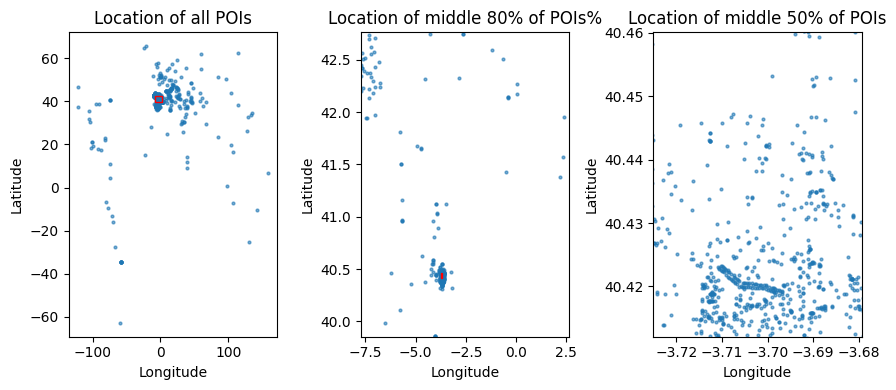

In [ ]:
# make three scatter graphs of latitude vs longitude:
# one global, one zoomed in, one zoomed in further

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# define quantile bounds for center plot (80% of data)
lq_1 = 0.1 # lower quantile
uq_1 = 0.9 # upper quantile

# define quantile bounds for right-side plot (50% of data)
lq_2 = 0.25 # lower quantile
uq_2 = 0.75 # upper quantile

# compute zoom bounds for center plot
lon_min_1 = df["locationLon"].quantile(lq_1)
lon_max_1 = df["locationLon"].quantile(uq_1)
lat_min_1 = df["locationLat"].quantile(lq_1)
lat_max_1 = df["locationLat"].quantile(uq_1)

# compute zoom bounds for right-side plot
lon_min_2 = df["locationLon"].quantile(lq_2)
lon_max_2 = df["locationLon"].quantile(uq_2)
lat_min_2 = df["locationLat"].quantile(lq_2)
lat_max_2 = df["locationLat"].quantile(uq_2)

# set up the graphs
#fig, axes = plt.subplots(1, 3, figsize=(9, 4))
fig, axes = plt.subplots(1, 3, figsize=(9, 4))

# left side: full extent
axes[0].scatter(df["locationLon"],df["locationLat"],s=4,alpha=0.6)
axes[0].set_title("Location of all POIs")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# center: zooming in to view 80% of the data
axes[1].scatter(df["locationLon"], df["locationLat"],s=4,alpha=0.6)
axes[1].set_xlim(df["locationLon"].quantile(lq_1),
                 df["locationLon"].quantile(uq_1))
axes[1].set_ylim(df["locationLat"].quantile(lq_1),
                 df["locationLat"].quantile(uq_1))
axes[1].set_title("Location of middle 80% of POIs%")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

# right: zooming in to view 50% of the data
axes[2].scatter(df["locationLon"], df["locationLat"],s=4,alpha=0.6)
axes[2].set_xlim(df["locationLon"].quantile(lq_2),
                 df["locationLon"].quantile(uq_2))
axes[2].set_ylim(df["locationLat"].quantile(lq_2),
                 df["locationLat"].quantile(uq_2))
axes[2].set_title("Location of middle 50% of POIs")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")

# add zooming rectangle to left-side plot
zoom_rect = Rectangle(
    (lon_min_1, lat_min_1),
    lon_max_1 - lon_min_1,
    lat_max_1 - lat_min_1,
    fill=False,
    linewidth=1,
    color = 'red'
)
axes[0].add_patch(zoom_rect)

# add zooming rectangle to center plot
zoom_rect = Rectangle(
    (lon_min_2, lat_min_2),
    lon_max_2 - lon_min_2,
    lat_max_2 - lat_min_2,
    fill=False,
    linewidth=1,
    color = 'red'
)
axes[1].add_patch(zoom_rect)
plt.tight_layout()
plt.show()


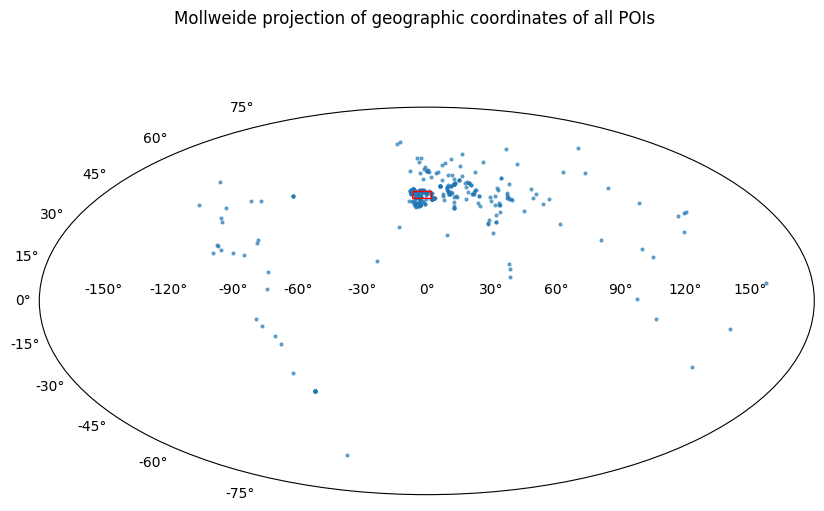

In [ ]:
# Use Mollveide projection to make one global graph
# of geographic coordinates

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# use quantile bounds from previous graphs for adding the two rectangles
#lq_1 = 0.1 # lower quantile
#uq_1 = 0.9 # upper quantile
#lq_2 = 0.25 # lower quantile
#uq_2 = 0.75 # upper quantile

# use zoom bounds of lon/lat from previous graphs for the rectangles
#lon_min_1 = df["locationLon"].quantile(lq_1)
#lon_max_1 = df["locationLon"].quantile(uq_1)
#lat_min_1 = df["locationLat"].quantile(lq_1)
#lat_max_1 = df["locationLat"].quantile(uq_1)

#lon_min_2 = df["locationLon"].quantile(lq_2)
#lon_max_2 = df["locationLon"].quantile(uq_2)
#lat_min_2 = df["locationLat"].quantile(lq_2)
#lat_max_2 = df["locationLat"].quantile(uq_2)

# prepare graph
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection = "mollweide")
plt.suptitle("Mollweide projection of geographic coordinates of all POIs")

# convert latitude and longitude to radians
lon_rad = np.deg2rad(df['locationLon'])
lat_rad = np.deg2rad(df['locationLat'])

ax.scatter(lon_rad, lat_rad, s=4,alpha=0.6)

# add zooming rectangles
zoom_rect1 = Rectangle(
    (np.deg2rad(lon_min_1), np.deg2rad(lat_min_1)),
    np.deg2rad(lon_max_1) - np.deg2rad(lon_min_1),
    np.deg2rad(lat_max_1) - np.deg2rad(lat_min_1),
    fill=False,
    linewidth=1,
    color = 'red'
)
ax.add_patch(zoom_rect1)

zoom_rect2 = Rectangle(
    (np.deg2rad(lon_min_2), np.deg2rad(lat_min_2)),
    np.deg2rad(lon_max_2) - np.deg2rad(lon_min_2),
    np.deg2rad(lat_max_2) - np.deg2rad(lat_min_2),
    fill=False,
    linewidth=1,
    color = 'red'
)
ax.add_patch(zoom_rect2)

# plot graph
plt.show()


In [ ]:
# create dataframe 'counts_per_row' containing the
# 'tags' count and 'categories' count per row.
counts_per_row = df.assign(
    num_tags=df["tags"].apply(len),
    num_categories=df["categories"].apply(len)
)[["num_tags", "num_categories"]]

# display the summary statistics
counts_per_row.describe()

,num_tags,num_categories
count,1492.000000,1492.000000
mean,8.920912,3.024799
std,4.275762,0.646967
min,0.000000,0.000000
25%,5.000000,3.000000
50%,10.000000,3.000000
75%,13.000000,3.000000
max,13.000000,4.000000


##e. Assessment of images

In this section I explore the images to evaluate:
* whether they all have the same format (size and color mode)
* their overall quality (contrast, brightness and sharpness)

In [ ]:
# check the properties (size and color mode)
# and also the quality (contrast, brightness and sharpness)

# import libraries
import pandas as pd
import cv2 as cv
from PIL import Image

# initialize list to store image information
image_data = []

# iterating over each 'df' row: open image, get information and store it
for index, row in df.iterrows():

  # read the image
  image_path = prefix_path + row['main_image_path']
  #img = Image.open(image_path)  # open the image
  img = cv.imread(image_path)

  # get the image data type
  data_type = img.dtype

  # get the dimensions
  height, width, channels = img.shape

  # get the color mode (RGB, BGR or other)
  if channels == 3:
    color_mode = 'BGR'
  elif channels == 1:
    color_mode = 'gray'
  else:
    color_mode = 'unexpected'

  # extract darkest and lightest pixels of image
  img_min_pixel = img.min()
  img_max_pixel = img.max()

  # convert to grayscale image
  img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

  # extract darkest and lightest pixels of grayscale image
  img_gray_min_pixel = img_gray.min()
  img_gray_max_pixel = img_gray.max()

  # calculate Laplacian of grayscale image
  laplacian = cv.Laplacian(img_gray, cv.CV_64F)

  # calculate contrast using standard deviation of grayscale image
  contrast = np.std(img_gray)

  # calculate brightness using mean intensity of grayscale image
  brightness = np.mean(img_gray)

  # calculate sharpness using variance of Laplacian
  sharpness = np.var(laplacian)

  # append the information into the image_data list
  image_data.append({
      'id': row['id'],
      'main_image_path': image_path,
      'width': width,
      'height': height,
      'channels':channels,
      'color_mode':color_mode,
      'image_min_pixel':img_min_pixel,
      'image_max_pixel':img_max_pixel,
      'gray_image_min_pixel':img_gray_min_pixel,
      'gray_image_max_pixel':img_gray_max_pixel,
      'contrast': contrast,
      'brightness':brightness,
      'sharpness': sharpness
  })

# create pandas dataframe with image information
df_images = pd.DataFrame(image_data)

# display summary statistics
df_images.describe()


,width,height,channels,image_min_pixel,image_max_pixel,gray_image_min_pixel,gray_image_max_pixel,contrast,brightness,sharpness
count,1492.0,1492.0,1492.0,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000
mean,128.0,128.0,3.0,11.574397,220.681635,15.826408,215.422252,48.779266,114.737123,1270.430008
std,0.0,0.0,0.0,24.845367,50.034902,27.423817,52.122785,19.709249,40.708310,2057.139075
min,128.0,128.0,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,128.0,128.0,3.0,0.000000,200.000000,0.000000,191.000000,33.888967,88.252014,39.368611
50%,128.0,128.0,3.0,0.000000,250.000000,1.000000,239.000000,50.430631,115.881348,198.558890
75%,128.0,128.0,3.0,13.000000,255.000000,24.000000,255.000000,63.127898,140.359299,1907.059712
max,128.0,128.0,3.0,255.000000,255.000000,255.000000,255.000000,113.060352,255.000000,14834.004764


In [ ]:
df_images.head(2)

,id,main_image_path,width,height,channels,color_mode,image_min_pixel,image_max_pixel,gray_image_min_pixel,gray_image_max_pixel,contrast,brightness,sharpness
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,/content/drive/My Drive/KeepCoding/DeepLearnin...,128,128,3,BGR,0,255,12,255,37.379179,216.841003,962.505682
1,e32b3603-a94f-49df-8b31-92445a86377c,/content/drive/My Drive/KeepCoding/DeepLearnin...,128,128,3,BGR,0,255,5,255,75.460625,145.115112,1890.872480


In [ ]:
print(df_images.columns)

Index(['id', 'main_image_path', 'width', 'height', 'channels', 'color_mode',
       'image_min_pixel', 'image_max_pixel', 'gray_image_min_pixel',
       'gray_image_max_pixel', 'contrast', 'brightness', 'sharpness'],
      dtype='object')


In [ ]:
print(df_images.dtypes)

id                       object
main_image_path          object
width                     int64
height                    int64
channels                  int64
color_mode               object
image_min_pixel           uint8
image_max_pixel           uint8
gray_image_min_pixel      uint8
gray_image_max_pixel      uint8
contrast                float64
brightness              float64
sharpness               float64
dtype: object


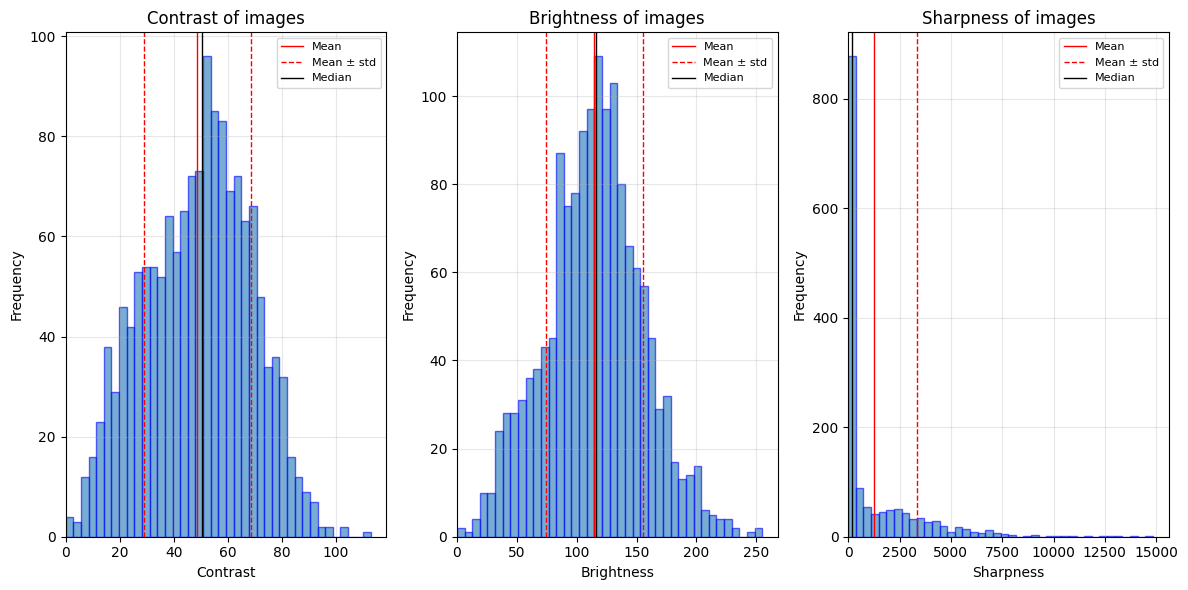

In [ ]:
# make frequency distribution graphs for image contrast, brightness, and sharpness

import matplotlib.pyplot as plt

# create the figure and axes (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
#fig.suptitle("Distribution of image quality")

variables = ['contrast', 'brightness', 'sharpness']
axes = axes.flatten()  # to make indexing easier

for ax, var in zip(axes, variables):
  img_data = df_images[var]

  # calculate mean, standard deviation, median
  mean = img_data.mean()
  std = img_data.std()
  median = img_data.median()

  # create histogram
  ax.hist(df_images[var], bins=40, edgecolor='blue',alpha=0.6)  # bins = number of buckets to represent all data

  # red solid line: mean
  ax.axvline(mean, color = 'red', linewidth=1, label = "Mean")

  # red dashed lines: mean +- std
  ax.axvline(mean - std, color = 'red', linestyle = '--', linewidth=1, label = "Mean ± std")
  ax.axvline(mean + std, color = 'red', linestyle = '--', linewidth=1)

  # black solid line: median
  ax.axvline(median, color = 'black', linewidth=1, label = "Median")

  #force horizontal axis to start at 0
  ax.set_xlim(left=0)

  # labels and grid
  ax.set_title(f"{var.capitalize()} of images")
  ax.set_xlabel(var.capitalize())
  ax.set_ylabel("Frequency")
  ax.grid(True, alpha=0.3)

  # legend (without repeating)
  handles, labels = ax.get_legend_handles_labels()
  by_label = dict(zip(labels, handles))
  ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

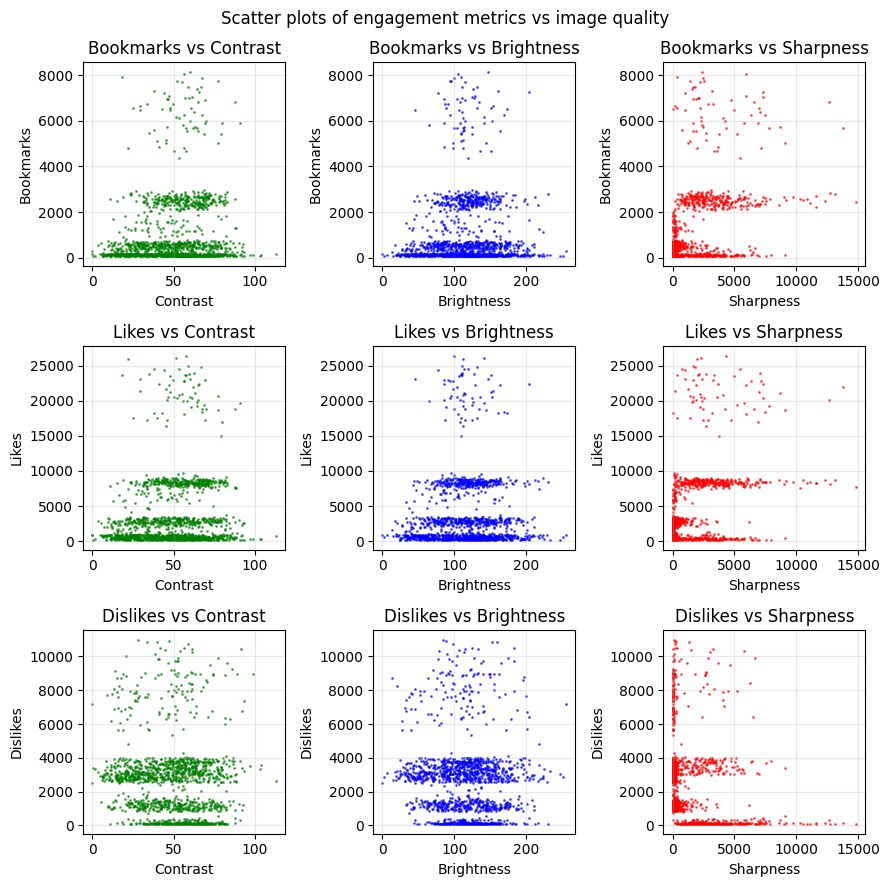

In [ ]:
# draw graphs of engagement-related variables vs 'contrast', 'brightness', and 'sharpness'

import matplotlib.pyplot as plt

# create the figure and axes for 9 plots (3 rows, 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
fig.suptitle("Scatter plots of engagement metrics vs image quality")

# x and y variables
x_vars = ['contrast', 'brightness', 'sharpness']  # in df_images
y_vars = ['Bookmarks', 'Likes', 'Dislikes']       # in df

# define a color for each x_var
colors = ['green', 'blue', 'red']

# loop over x_vars and y_vars to create each scatter plot
for i, x_var in enumerate(x_vars):
  for j, y_var in enumerate (y_vars):
    # access appropriate scatter plot
    ax = axes[j, i]

    # create scatter plot
    ax.scatter(df_images[x_var], df[y_var], s = 1, alpha = 0.6, color = colors[i])

    # set title and labels
    ax.set_title(f"{y_var} vs {x_var.capitalize()}")
    ax.set_xlabel(x_var.capitalize())
    ax.set_ylabel(y_var)

    # add gridlines for better readabilitly
    ax.grid(True, alpha = 0.3)

# improve layout
plt.tight_layout()
plt.show()


The code snippet below is just to see whether the number of Bookmarks ever exceeds the number of reactions (Likes + Dislikes).

In [ ]:
# count how many rows match the condition: 'Bookmarks' > ('Likes' + 'Dislikes')
cond = df["Bookmarks"] > (df["Likes"] + df["Dislikes"])
count = cond.sum()

# display the count
print(f"Number of rows where Bookmarks > Likes + Dislikes: {count}")

Number of rows where Bookmarks > Likes + Dislikes: 0


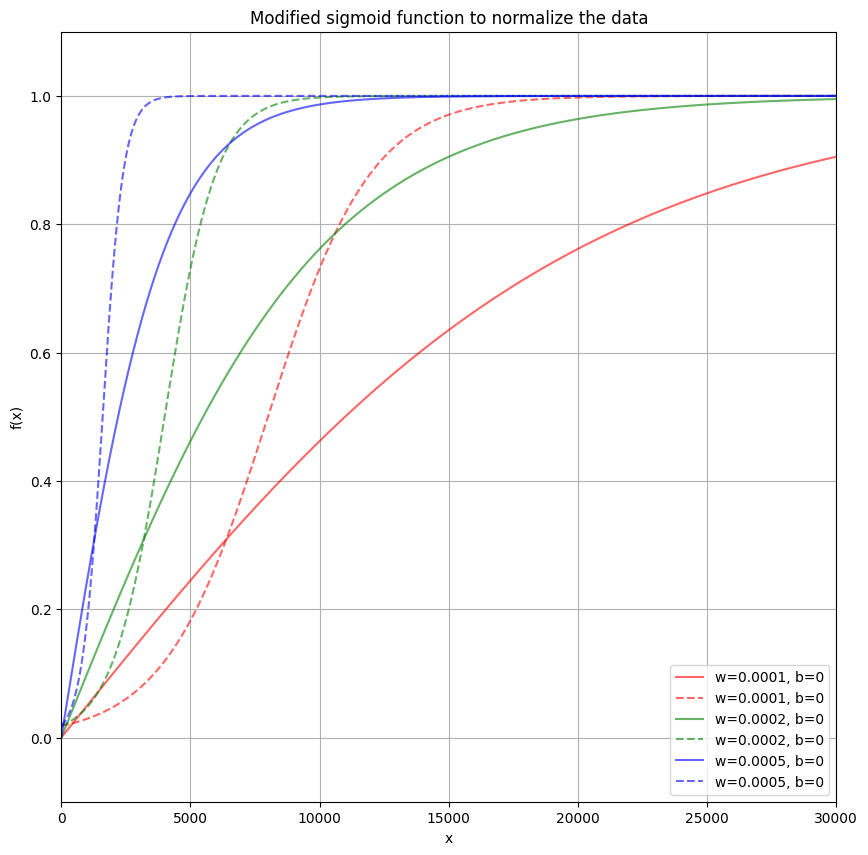

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x, w, b):
    return 1 / (1 + np.exp(-(w * x + b)))

x = np.linspace(0, 30000, 30000)

plt.figure(figsize=(10, 10))
plt.title("Modified sigmoid function to normalize the data")
plt.xlabel("x")
plt.ylabel("f(x)")

weights = [0.0001,0.0002, 0.0005]
colors = ['r', 'g', 'b']

for w, c in zip(weights, colors):
    y = 2 * sigmoid(x, w, 0) - 1
    plt.plot(x, y, c, label=f'w={w}, b=0', alpha=0.6)
    y_2 = sigmoid(x, 5*w, -4)
    plt.plot(x, y_2, c, label=f'w={w}, b=0', alpha=0.6, linestyle='dashed')

plt.xlim(0, 30000)  # Set x-axis limits
plt.ylim(-0.1, 1.1)  # Set y-axis limits

plt.legend()
plt.grid(True)
plt.show()

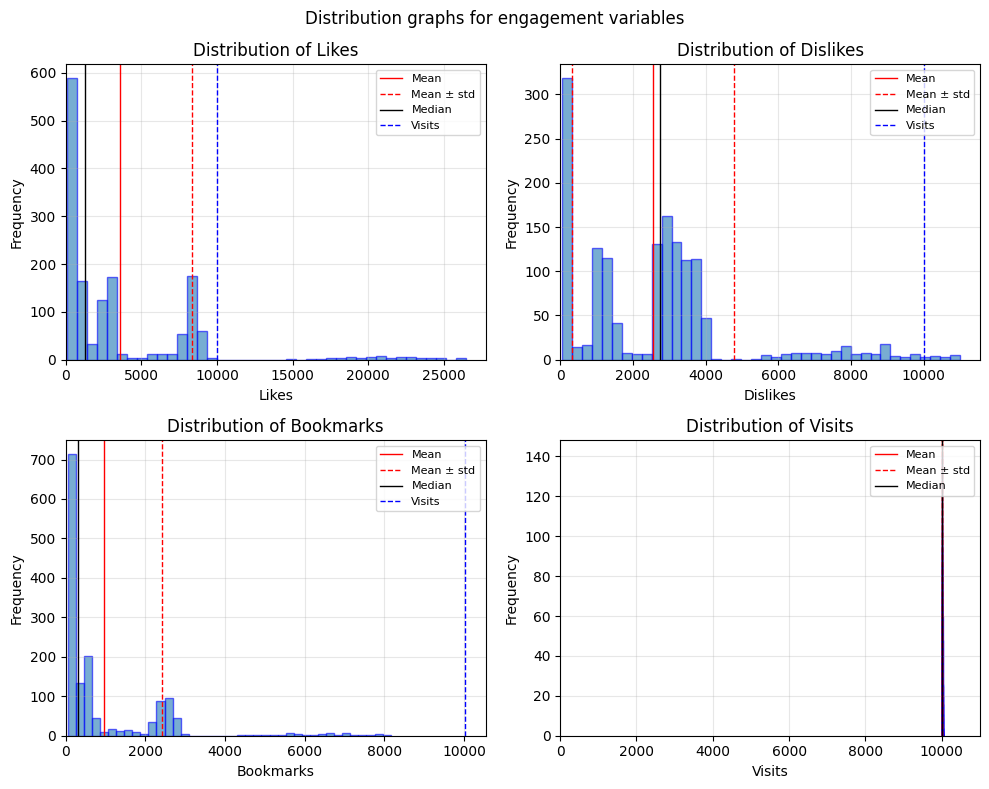

In [ ]:
# make frequency distribution graphs for engagement variables

import matplotlib.pyplot as plt

# create the figure and axes (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Distribution graphs for engagement variables")

variables = ['Likes', 'Dislikes', 'Bookmarks', 'Visits']
axes = axes.flatten()  # to make indexing easier

for ax, var in zip(axes, variables):
  data = df[var]

  # calculate mean, standard deviation, median
  mean = data.mean()
  std = data.std()
  median = data.median()

  # create histogram
  ax.hist(df[var], bins=40, edgecolor='blue',alpha=0.6)  # bin = number of buckets to represent all data

  # red solid line: mean
  ax.axvline(mean, color = 'red', linewidth=1, label = "Mean")

  # red dashed lines: mean +- std
  ax.axvline(mean - std, color = 'red', linestyle = '--', linewidth=1, label = "Mean ± std")
  ax.axvline(mean + std, color = 'red', linestyle = '--', linewidth=1)

  # green solid line: median
  ax.axvline(median, color = 'black', linewidth=1, label = "Median")

  # black dashed line: mean of 'Visits' (except for Visits graph)
  if var != 'Visits':
        ax.axvline(10012, color="blue", linestyle="--", linewidth=1, label="Visits")

  #force horizontal axis to start at 0
  if var == 'Visits':
    ax.set_xlim(left=0, right = 11000)  # force axis to extend slightly after, for visibility
  else:
    ax.set_xlim(left=0)

  # labels and grid
  ax.set_title(f"Distribution of {var}")
  ax.set_xlabel(var)
  ax.set_ylabel("Frequency")
  ax.grid(True, alpha=0.3)

  # legend (without repeating)
  handles, labels = ax.get_legend_handles_labels()
  by_label = dict(zip(labels, handles))
  ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

The data looks far from normally-distributed, the "best" being 'Visits'but with a tiny variability.

In [ ]:
# Save cleaned up dataframe to csv
df.to_csv(prefix_path + "poi_clean.csv", index=False)